# GC Example 14: Sagittarius Stream Clusters

**EPS Research — Milky Way GC Corpus v1.3.2**

Some GCs were accreted with the Sagittarius dwarf galaxy.
The corpus flags these with sgr_stream=True.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


Sgr stream GCs: 6
Non-Sgr GCs:    168

Sgr stream clusters:
  Whiting 1    [Fe/H]=-0.7  mass=1370
  NGC 6715     [Fe/H]=-1.49  mass=1290000
  Terzan 7     [Fe/H]=-0.32  mass=27800
  Arp 2        [Fe/H]=-1.75  mass=52400
  Terzan 8     [Fe/H]=-2.16  mass=39900
  Pal 12       [Fe/H]=-0.85  mass=22900


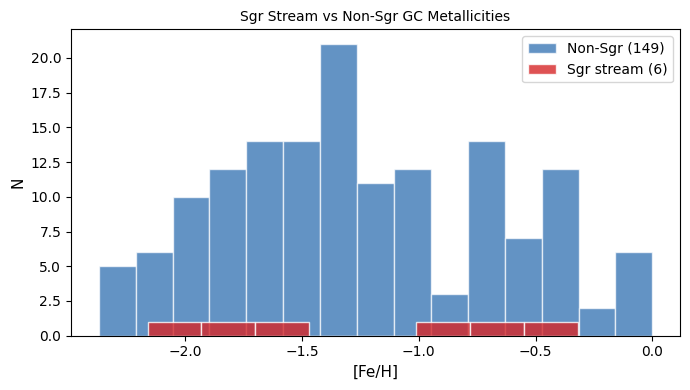

In [3]:
sgr=[c for c in clusters if c.get('flags',{}).get('sgr_stream',False)]
non_sgr=[c for c in clusters if not c.get('flags',{}).get('sgr_stream',False)]
print(f"Sgr stream GCs: {len(sgr)}")
print(f"Non-Sgr GCs:    {len(non_sgr)}")
print(f"\nSgr stream clusters:")
for c in sgr:
    b=c.get('baumgardt2023',{})
    feh=c.get('metallicity',{}).get('feh','?')
    mass=b.get('mass_msun','?') if b else '?'
    print(f"  {c['cluster_id']:<12} [Fe/H]={feh}  mass={'N/A' if not isinstance(mass,float) else f'{mass:.0f}'}")
sgr_feh=[c['metallicity']['feh'] for c in sgr
         if c.get('metallicity') and c['metallicity'].get('feh') is not None]
non_feh=[c['metallicity']['feh'] for c in non_sgr
         if c.get('metallicity') and c['metallicity'].get('feh') is not None]
fig,ax=plt.subplots(figsize=(7,4))
ax.hist(non_feh,bins=15,alpha=0.7,color='#2166ac',label=f'Non-Sgr ({len(non_feh)})',edgecolor='white')
ax.hist(sgr_feh,bins=8,alpha=0.8,color='#d62728',label=f'Sgr stream ({len(sgr_feh)})',edgecolor='white')
ax.set_xlabel('[Fe/H]',fontsize=11); ax.set_ylabel('N',fontsize=11)
ax.set_title('Sgr Stream vs Non-Sgr GC Metallicities',fontsize=10)
ax.legend(); plt.tight_layout()
plt.savefig('gc14_sgr_stream.png',dpi=150,bbox_inches='tight'); plt.show()